<a href="https://colab.research.google.com/github/fankewe/ml-currency-volatility/blob/main/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving EURUSD_M15_2023_2025.csv to EURUSD_M15_2023_2025.csv


In [2]:
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("EURUSD_M15_2023_2025.csv")

print(df.columns)
df.head()

Index(['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread',
       'real_volume'],
      dtype='object')


,time,open,high,low,close,tick_volume,spread,real_volume
0,2023-01-02 07:00:00,1.07016,1.07017,1.06909,1.06972,20,7,0
1,2023-01-02 07:15:00,1.06969,1.06979,1.06930,1.06938,15,7,0
2,2023-01-02 07:30:00,1.06929,1.06969,1.06929,1.06951,164,5,0
3,2023-01-02 07:45:00,1.06951,1.07001,1.06945,1.06967,141,1,0
4,2023-01-02 08:00:00,1.06971,1.06989,1.06936,1.06952,88,7,0


In [3]:
# ===== 1. 时间处理 =====
df["timestamp"] = pd.to_datetime(df["time"])
df = df.sort_values("timestamp")

# ===== 2. 价格 =====
df["price"] = df["close"]

# ===== 3. log return =====
import numpy as np

df["log_price"] = np.log(df["price"])
df["return"] = df["log_price"].diff()

# ===== 4. volatility（核心）=====
df["volatility"] = df["return"].rolling(20).std()

df = df.dropna()

df.head()

,time,open,high,low,close,tick_volume,spread,real_volume,timestamp,price,log_price,return,volatility
20,2023-01-02 12:00:00,1.06788,1.06854,1.06779,1.06846,202,0,0,2023-01-02 12:00:00,1.06846,0.066218,0.000580,0.000355
21,2023-01-02 12:15:00,1.06846,1.06898,1.06820,1.06822,239,3,0,2023-01-02 12:15:00,1.06822,0.065994,-0.000225,0.000352
22,2023-01-02 12:30:00,1.06822,1.06872,1.06749,1.06771,174,1,0,2023-01-02 12:30:00,1.06771,0.065516,-0.000478,0.000362
23,2023-01-02 12:45:00,1.06778,1.06836,1.06763,1.06836,166,0,0,2023-01-02 12:45:00,1.06836,0.066125,0.000609,0.000391
24,2023-01-02 13:00:00,1.06836,1.06854,1.06804,1.06848,193,0,0,2023-01-02 13:00:00,1.06848,0.066237,0.000112,0.000392


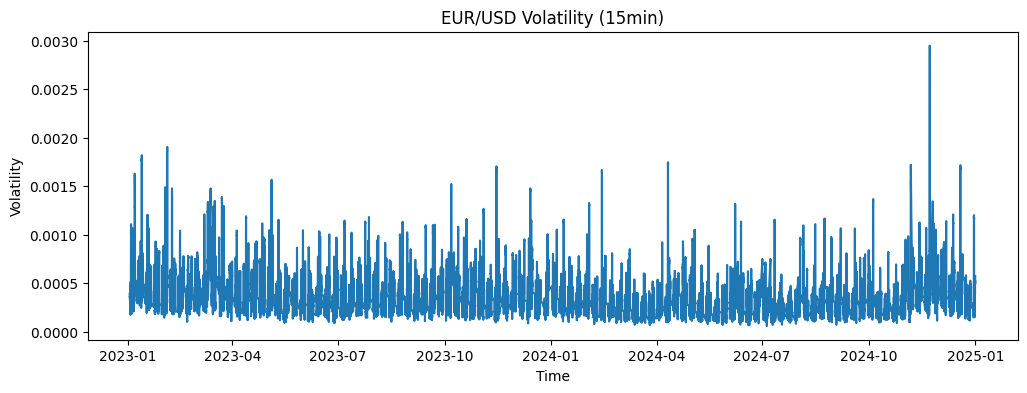

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df["timestamp"], df["volatility"])
plt.title("EUR/USD Volatility (15min)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()